# number density for different target selection scenarios

In [1]:
import numpy as np 
from astropy.table import Table

In [2]:
from astropy.cosmology import Planck18

In [3]:
# --- plotting ---
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False

In [4]:
# Kota's catalog with VI-ed redsifts
kota = Table.read('/Users/hahnchanghoon/data/pfs/kota_vi_run21_extra.fits')
print('%i objects' % len(kota))

7449 objects


In [5]:
g_mag_kota = kota['g_cmodel_mag_2'] - kota['a_g']
r_mag_kota = kota['r_cmodel_mag_2'] - kota['a_r']
i_mag_kota = kota['i_cmodel_mag_2'] - kota['a_i']
z_mag_kota = kota['z_cmodel_mag_2'] - kota['a_z']

In [6]:
# LAM 1D reduction for S25a sent by Jingjing
lam1d = Table.read('/Users/hahnchanghoon/data/pfs/lam1d_s25a_matched.fits')
print('%i objects' % len(lam1d))

61684 objects


In [7]:
# compile HSC photometry
# extinction corrected magnitudes 
g_mag_lam = lam1d['g_cmodel_mag'] - lam1d['a_g']
r_mag_lam = lam1d['r_cmodel_mag'] - lam1d['a_r']
i_mag_lam = lam1d['i_cmodel_mag'] - lam1d['a_i']
z_mag_lam = lam1d['z_cmodel_mag'] - lam1d['a_z']

## color-magnitude cuts
We will explore multiple color-magnitude cuts: 

1. low-$z$ cuts: removes low-$z$ contaminants
2. $i-z$ color cut reduces the color-space to higher-z objects
3. $i$ magnitude cut to explore less faint objects

In [8]:
rm_lowz_kota = (((i_mag_kota - z_mag_kota) > 2 * (g_mag_kota - r_mag_kota) - 0.55) & #$(i-z) > 2 (g-r) - 0.55
                ((i_mag_kota - z_mag_kota) > -0.1))
print(np.mean(rm_lowz_kota))
rm_lowz_lam = (((i_mag_lam - z_mag_lam) > 2 * (g_mag_lam - r_mag_lam) - 0.55) & #$(i-z) > 2 (g-r) - 0.55
               ((i_mag_lam - z_mag_lam) > -0.1))
print(np.mean(rm_lowz_lam))

0.9383809907370116
0.9357166018158236


In [9]:
# i-z color cut
iz_cut0_kota = (i_mag_kota - z_mag_kota) < 0.4
iz_cut0_lam = (i_mag_lam - z_mag_lam) < 0.4

iz_cut1_kota = (i_mag_kota - z_mag_kota) < 0.25
iz_cut1_lam = (i_mag_lam - z_mag_lam) < 0.25

In [10]:
# diagonal cut
diag_cut0_kota = (i_mag_kota - z_mag_kota) > 2 * (g_mag_kota - r_mag_kota) - 0.45
diag_cut0_lam = (i_mag_lam - z_mag_lam) > 2 * (g_mag_lam - r_mag_lam) - 0.45

In [11]:
i23p8_kota = (i_mag_kota < 23.8)
i23p8_lam = (i_mag_lam < 23.8)

i23p6_kota = (i_mag_kota < 23.6)
i23p6_lam = (i_mag_lam < 23.6)

## redshift success criteria

In [12]:
pass_vi = 0.5*(kota['user1'] + kota['user2']) >= 4
print(np.mean(pass_vi))
lam_best = ((lam1d['probaGalaxy'] > 0.99) & 
           (lam1d['redshiftProba'] > 0.99) & 
           (lam1d['redshiftError'] < 0.01))
print(np.mean(lam_best))

0.34137744034707157
0.6366967122754685


# number density estimates
For various scenarios: 
1. Vanilla March run TS with ~17,000 objects/deg^2
2. (March Run) + (low-z cut to remove contaminants)
3. (March Run) + (low-z cut) + ($i-z$ cut)
4. (March Run) + (low-z cut) + ($i-z$ cut) + (reduced $i$ magnitude faint limit)

In [13]:
ng_desi_elg = np.array([[0.7983182049170272, 2.00130548302872], 
                        [0.9136760299297317, 2.412532637075717], 
                        [0.9968282895543836, 2.31462140992167], 
                        [1.087741163895071, 2.0078328981723232], 
                        [1.1910999351639302, 1.8381201044386422], 
                        [1.2818813850386388, 1.6618798955613574], 
                        [1.4028970333117212, 1.4530026109660574], 
                        [1.4785580983755935, 1.296344647519582],
                        [1.4990011740585627, 0.9895561357702345],
                        [1.5344266388630907, 0.8002610966057437],
                        [1.587278987856379, 0.8002610966057437]])

In [14]:
def f_assign(selection): 
    ''' estimated fiber assignment fraction 
    # 0.97 @ 6000 and 0.8 @ 3000
    '''
    Ntarget = 17000. * np.mean(selection)
    return np.clip((Ntarget - 3000.0)/17000. + 0.8, 0., 1.) 

def nz_kota(selection, zmin, zmax, target=True): 
    ''' number density of success redshifts for given selection per square degree --- based on Kota's catalog
    '''
    _zlim = (kota['z_measured'] > zmin) & (kota['z_measured'] < zmax) # redshift limit
    _fassign = f_assign(selection)

    Nz = 2900. / 1.25 * _fassign * (np.sum(selection & pass_vi & _zlim) / np.sum(selection))

    # calculate comoving volume of 1 sq.deg
    _Vol = (1/41253. * (Planck18.comoving_volume(zmax) - Planck18.comoving_volume(zmin)) * Planck18.h**3).value
    return Nz / _Vol

def nz_lam(selection, zmin, zmax): 
    ''' Number of success redshifts for given selection per square degree --- based on LAM1D
    '''
    _zlim = (lam1d['redshift'] > zmin) & (lam1d['redshift'] < zmax) # redshift limit
    _fassign = f_assign(selection)
    
    Nz = 2900. / 1.25 * _fassign * (np.sum(selection & lam_best & _zlim) / np.sum(selection))
        
    # calculate comoving volume of 1 sq.deg
    _Vol = (1/41253. * (Planck18.comoving_volume(zmax) - Planck18.comoving_volume(zmin)) * Planck18.h**3).value
    return Nz / _Vol

In [15]:
zmid, ng1_kota, ng2_kota, ng3_kota, ng4_kota, ng5_kota, ng6_kota, ng7_kota = [], [], [], [], [], [], [], []
for zmin, zmax in zip([0.6, 0.8, 1., 1.2, 1.4, 1.6, 2.], [0.8, 1., 1.2, 1.4, 1.6, 2., 2.2]): 
    zmid.append(0.5*(zmin + zmax))
    
    ng1_kota.append(nz_kota(np.ones(len(kota)).astype(bool), zmin, zmax))
    ng2_kota.append(nz_kota(rm_lowz_kota, zmin, zmax))
    ng3_kota.append(nz_kota(rm_lowz_kota & iz_cut0_kota, zmin, zmax))
    ng4_kota.append(nz_kota(rm_lowz_kota & iz_cut0_kota & i23p8_kota, zmin, zmax))
    ng5_kota.append(nz_kota(rm_lowz_kota & iz_cut1_kota & i23p8_kota, zmin, zmax)) 
    ng6_kota.append(nz_kota(rm_lowz_kota & iz_cut0_kota & i23p6_kota, zmin, zmax))     
    ng7_kota.append(nz_kota(rm_lowz_kota & iz_cut0_kota & diag_cut0_kota & i23p8_kota, zmin, zmax))

In [16]:
ng1_lam, ng2_lam, ng3_lam, ng4_lam, ng5_lam, ng6_lam, ng7_lam = [], [], [], [], [], [], []
for zmin, zmax in zip([0.6, 0.8, 1., 1.2, 1.4, 1.6, 2.], [0.8, 1., 1.2, 1.4, 1.6, 2., 2.2]): 
    ng1_lam.append(nz_lam(np.ones(len(lam1d)).astype(bool), zmin, zmax))
    ng2_lam.append(nz_lam(rm_lowz_lam, zmin, zmax))
    ng3_lam.append(nz_lam(rm_lowz_lam & iz_cut0_lam, zmin, zmax))
    ng4_lam.append(nz_lam(rm_lowz_lam & iz_cut0_lam & i23p8_lam, zmin, zmax))
    ng5_lam.append(nz_lam(rm_lowz_lam & iz_cut1_lam & i23p8_lam, zmin, zmax))    
    ng6_lam.append(nz_lam(rm_lowz_lam & iz_cut0_lam & i23p6_lam, zmin, zmax))    
    ng7_lam.append(nz_lam(rm_lowz_lam & iz_cut0_lam & diag_cut0_lam & i23p6_lam, zmin, zmax))

In [17]:
zmid = np.array(zmid)
ng1_kota = np.array(ng1_kota)
ng2_kota = np.array(ng2_kota)
ng3_kota = np.array(ng3_kota)
ng4_kota = np.array(ng4_kota)
ng5_kota = np.array(ng5_kota)
ng6_kota = np.array(ng6_kota)
ng7_kota = np.array(ng7_kota)


ng1_lam = np.array(ng1_lam)
ng2_lam = np.array(ng2_lam)
ng3_lam = np.array(ng3_lam)
ng4_lam = np.array(ng4_lam)
ng5_lam = np.array(ng5_lam)
ng6_lam = np.array(ng6_lam)
ng7_lam = np.array(ng7_lam)

(1e-06, 0.002)

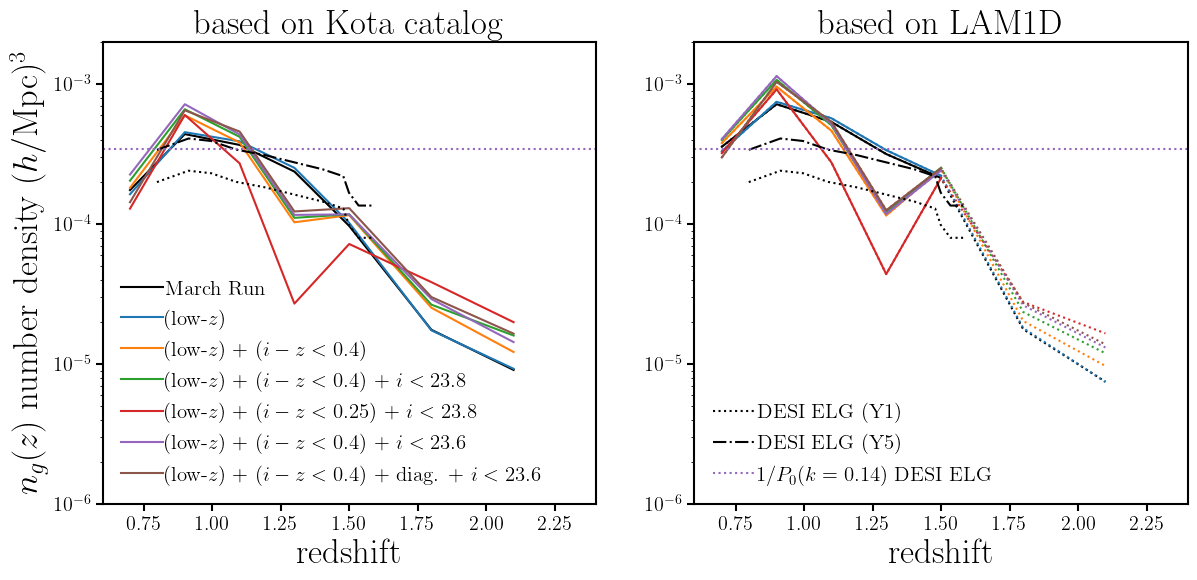

In [18]:
fig = plt.figure(figsize=(14,6))
sub = fig.add_subplot(121)

# based on KOTA
sub.plot(zmid, ng1_kota, color='k', label='March Run')
sub.plot(zmid, ng2_kota, color='C0', label='(low-$z$)')
sub.plot(zmid, ng3_kota, color='C1', label='(low-$z$) + ($i-z < 0.4$)')
sub.plot(zmid, ng4_kota, color='C2', label='(low-$z$) + ($i-z < 0.4$) + $i < 23.8$')
sub.plot(zmid, ng5_kota, color='C3', label='(low-$z$) + ($i-z < 0.25$) + $i < 23.8$')
sub.plot(zmid, ng6_kota, color='C4', label='(low-$z$) + ($i-z < 0.4$) + $i < 23.6$')
sub.plot(zmid, ng7_kota, color='C5', label='(low-$z$) + ($i-z < 0.4$) + diag. + $i < 23.6$')


# reference n(z)
sub.plot(ng_desi_elg[:,0], ng_desi_elg[:,1]*1e-4, c='k', ls=':')
sub.plot(ng_desi_elg[:,0], 60/35.3*ng_desi_elg[:,1]*1e-4, c='k', ls='-.')

#sub.axhline(1.5e-4, c='r', ls='--', label='Recon. bias limit')
sub.axhline(1./(2.9e3), c='C4', ls=':')

sub.set_title('based on Kota catalog', fontsize=25)

sub.legend(loc='lower left', fontsize=15, handletextpad=0.1)
sub.set_xlabel('redshift', fontsize=25)
sub.set_xlim(0.6, 2.4)
sub.set_ylabel(r'$n_g(z)$ number density $(h/{\rm Mpc})^3$', fontsize=25)
sub.set_yscale('log')
sub.set_ylim(1e-6, 2e-3)


# based on LAM
sub = fig.add_subplot(122)
sub.plot(zmid, ng1_lam, color='k', ls=':')
sub.plot(zmid[zmid < 1.6], ng1_lam[zmid < 1.6], color='k')
sub.plot(zmid, ng2_lam, color='C0', ls=':')
sub.plot(zmid[zmid < 1.6], ng2_lam[zmid < 1.6], color='C0')
sub.plot(zmid, ng3_lam, color='C1', ls=':')
sub.plot(zmid[zmid < 1.6], ng3_lam[zmid < 1.6], color='C1')
sub.plot(zmid, ng4_lam, color='C2', ls=':')
sub.plot(zmid[zmid < 1.6], ng4_lam[zmid < 1.6], color='C2')
sub.plot(zmid, ng5_lam, ls=':', color='C3')
sub.plot(zmid[zmid < 1.6], ng5_lam[zmid < 1.6], color='C3')
sub.plot(zmid, ng6_lam, ls=':', color='C4')
sub.plot(zmid[zmid < 1.6], ng6_lam[zmid < 1.6], color='C4')
sub.plot(zmid, ng7_lam, ls=':', color='C5')
sub.plot(zmid[zmid < 1.6], ng7_lam[zmid < 1.6], color='C5')

# reference n(z)
sub.plot(ng_desi_elg[:,0], ng_desi_elg[:,1]*1e-4, c='k', ls=':', label='DESI ELG (Y1)')
sub.plot(ng_desi_elg[:,0], 60/35.3*ng_desi_elg[:,1]*1e-4, c='k', ls='-.', label='DESI ELG (Y5)')
#sub.axhline(1.5e-4, c='r', ls='--', label='Recon. bias limit')
sub.axhline(1./(2.9e3), c='C4', ls=':', label=r'$1/P_0(k=0.14)$ DESI ELG')

sub.set_title('based on LAM1D', fontsize=25)
sub.legend(loc='lower left', fontsize=15, handletextpad=0.1)
sub.set_xlabel('redshift', fontsize=25)
sub.set_xlim(0.6, 2.4)
sub.set_yscale('log')
sub.set_ylim(1e-6, 2e-3)